# Awinda (No-Exo) — gait-cycle joint moment profiles

Segments synced Awinda trials into heel-strike (HS) gait cycles and plots mean joint moment (N·m/kg) profiles.

Builds on [`process_awinda.ipynb`](process_awinda.ipynb):

- **GT moment**: OpenSim ID / mass, zero-phase 6 Hz LPF
- **Model moment**: IMU-based checkpoint inference, zero-phase 6 Hz LPF
- **Sync / trim**: Awinda-Vicon IK angle cross-correlation; drop first/last 15 s post-sync
- **HS detection**: vertical GRF (plate 2 = right foot, 50 N threshold crossing)
- **Joints**: hip_flexion_r, knee_angle_r, ankle_angle_r (right side)
- **Plots**: per trial type (condition), grand mean across subjects with each subject's mean cycle superimposed


In [1]:
import io
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, find_peaks, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')

EXO_KIND = 'awinda'
CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
CHANNEL_LABELS = [
    'Hip flexion (R)', 'Knee (R)', 'Ankle (R)',
    'Hip flexion (L)', 'Knee (L)', 'Ankle (L)',
]
# Focus on right side for HS-based gait cycles
RIGHT_CHANNELS = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']
RIGHT_LABELS = ['Hip flexion (R)', 'Knee (R)', 'Ankle (R)']

MOCAP_FS_HZ = 1000.0
DEFAULT_FS_HZ = 100.0

SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_PATH = CACHE_DIR / 'process_awinda.npz'
FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures' / 'awinda_gait_cycles'

LOAD_FROM_CACHE = True
EXCLUDE_SUBJECTS = {'AB02_Oscar'}  # Same as hip-exo

N_GAIT_PTS = 101
MIN_STRIDE_S = 0.40
MAX_STRIDE_S = 1.50

GRF_FORCE_THRESHOLD_N = 50.0
GRF_RIGHT_FOOT_COLUMN = 'ground_force2_vy'

SUBJECT_COLORS = {
    'AB01_Jinwoo': '#1f77b4',    # blue
    'AB03_Ilseung': '#ff7f0e',   # orange
    'AB04_Changseob': '#2ca02c', # green
    'AB05_Maria': '#d62728',     # red
    'AB06_Jimin': '#9467bd',     # purple
    'AB07_Amy': '#8c564b',       # brown
    'AB08_Seokhyun': '#e377c2',  # pink
}
SUBJECT_LINE_ALPHA = 0.50  # More transparent individual lines
GRAND_MEAN_COLOR = '#000000'  # black for grand mean
GRAND_MEAN_STD_COLOR = '#999999'  # gray for ± std band
GRAND_MEAN_STD_ALPHA = 0.3

print(f'Exo kind: {EXO_KIND} | cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | EXCLUDE_SUBJECTS={EXCLUDE_SUBJECTS}')
print(f'Right-side joints: {RIGHT_CHANNELS}')

Exo kind: awinda | cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz
LOAD_FROM_CACHE=True | EXCLUDE_SUBJECTS={'AB02_Oscar'}
Right-side joints: ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']


In [2]:
def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def trial_meta_from_key(trial_key: str) -> Dict[str, object]:
    """Parse 'AB01_Jinwoo::LG_0p8mps' → meta dict."""
    subject, condition = trial_key.split('::')
    task, speed = condition.split('_')
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': task,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': trial_key,
    }


def is_excluded_subject(subject_name: str) -> bool:
    return EXCLUDE_SUBJECTS is not None and subject_name in EXCLUDE_SUBJECTS


def load_awinda_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    """Load processed Awinda cache from process_awinda.ipynb."""
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        trial_key_str = str(trial_key)
        p = trial_key_str.replace('::', '__')  # Cache uses __ separator
        meta = data[f'{p}__meta']
        wave = {
            'trial_key': trial_key_str,
            'subject': str(meta[0]),
            'task': str(meta[1]),
            'condition': str(meta[2]),
            # Main synced & trimmed data
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'id_nmpkg': np.asarray(data[f'{p}__id_nmpkg'], dtype=np.float64),
            'pred_nmpkg': np.asarray(data[f'{p}__pred_nmpkg'], dtype=np.float64),
            'rmse_nmpkg': np.asarray(data[f'{p}__rmse_nmpkg'], dtype=np.float64),
            'r2_nmpkg': np.asarray(data[f'{p}__r2_nmpkg'], dtype=np.float64),
        }
        # Infer fs from time array
        if len(wave['t']) > 1:
            wave['fs_hz'] = 1.0 / np.median(np.diff(wave['t']))
        else:
            wave['fs_hz'] = DEFAULT_FS_HZ
        trial_data[trial_key_str] = wave
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data


print('Core helpers ready.')

Core helpers ready.


In [3]:
# HS detection (GRF-based: plate 2 = right foot)

def lowpass_grf(x, fs, cutoff=20, order=2):
    """Light lowpass for GRF smoothing."""
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)
    if valid.sum() < 10:
        return x.copy()
    nyq = 0.5 * float(fs)
    wn = float(np.clip(cutoff / nyq, 0.01, 0.99))
    sos = butter(int(order), wn, btype='low', output='sos')
    try:
        return sosfiltfilt(sos, x)
    except ValueError:
        return x.copy()


def detect_hs_from_grf(
    vy_force: np.ndarray,
    fs: float,
    force_threshold_n: float = GRF_FORCE_THRESHOLD_N,
    min_stride_time: float = MIN_STRIDE_S,
    max_stride_time: float = MAX_STRIDE_S,
) -> np.ndarray:
    vy = np.asarray(vy_force, dtype=float)
    n = len(vy)
    if n < 10 or fs <= 0:
        return np.array([], dtype=int)
    vy_smooth = lowpass_grf(vy, fs, cutoff=20, order=2)
    above_thresh = vy_smooth >= force_threshold_n
    hs_candidates = []
    for i in range(1, n):
        if not above_thresh[i-1] and above_thresh[i]:
            hs_candidates.append(i)
    if len(hs_candidates) < 2:
        return np.array([], dtype=int)
    hs = [hs_candidates[0]]
    for idx in hs_candidates[1:]:
        dt = (idx - hs[-1]) / fs
        if min_stride_time <= dt <= max_stride_time:
            hs.append(idx)
    return np.array(hs, dtype=int) if len(hs) >= 2 else np.array([], dtype=int)


def load_grf_on_time(trial_key: str, t_query: np.ndarray) -> np.ndarray:
    """Load vertical GRF for right foot (plate 2), interpolated onto t_query."""
    meta = trial_meta_from_key(trial_key)
    subject = meta['subject']
    condition = meta['condition']
    grf_path = PROCESSED_ROOT / subject / EXO_KIND / 'grf' / f'{condition}.mot'
    if not grf_path.exists():
        raise FileNotFoundError(f'GRF file not found: {grf_path}')
    cols, data = read_sto(grf_path)
    t_grf = data[:, cols.index('time')]
    vy_right = data[:, cols.index(GRF_RIGHT_FOOT_COLUMN)]
    vy_interp = np.interp(t_query, t_grf, vy_right, left=0.0, right=0.0)
    return vy_interp


def extract_moment_cycles(
    moment: np.ndarray,
    hs_events: np.ndarray,
    fs: float,
    n_pts: int = N_GAIT_PTS,
    min_stride_s: float = MIN_STRIDE_S,
    max_stride_s: float = MAX_STRIDE_S,
) -> Tuple[np.ndarray, np.ndarray]:
    pct = np.linspace(0.0, 100.0, n_pts)
    cycles: List[np.ndarray] = []
    hs_events = np.asarray(hs_events, dtype=int)
    for i in range(len(hs_events) - 1):
        start, end = int(hs_events[i]), int(hs_events[i + 1])
        if end <= start:
            continue
        dur = (end - start) / fs
        if dur < min_stride_s or dur > max_stride_s:
            continue
        seg = np.asarray(moment[start:end], dtype=np.float64)
        if seg.size < 4 or not np.all(np.isfinite(seg)):
            continue
        src_pct = np.linspace(0.0, 100.0, seg.size)
        cycles.append(np.interp(pct, src_pct, seg))
    return np.asarray(cycles), pct


def segment_trial_gait_cycles_multi_joint(trial_key: str, wave: Dict) -> Optional[Dict]:
    """Segment all right-side joints (hip, knee, ankle) using same HS events."""
    meta = trial_meta_from_key(trial_key)
    t = wave['t']  # Already synced and trimmed
    fs_hz = wave['fs_hz']
    id_nmpkg = wave['id_nmpkg']  # shape: (n, 6) for 6 joints
    pred_nmpkg = wave['pred_nmpkg']

    if t.size < 100:
        return None

    # Load GRF and detect HS
    vy_right = load_grf_on_time(trial_key, t)
    hs_events = detect_hs_from_grf(vy_right, fs_hz)
    if hs_events.size < 3:
        return None

    # Extract cycles for each right-side joint
    right_idx = [CHANNELS.index(c) for c in RIGHT_CHANNELS]
    gt_cycles_per_joint = []
    model_cycles_per_joint = []
    pct = None

    for j_idx in right_idx:
        gt_cyc, pct = extract_moment_cycles(id_nmpkg[:, j_idx], hs_events, fs_hz)
        model_cyc, _ = extract_moment_cycles(pred_nmpkg[:, j_idx], hs_events, fs_hz)
        if gt_cyc.size == 0 or model_cyc.size == 0:
            return None
        gt_cycles_per_joint.append(gt_cyc)
        model_cycles_per_joint.append(model_cyc)

    return {
        'trial_key': trial_key,
        **meta,
        'fs_hz': fs_hz,
        'n_hs': int(hs_events.size),
        'n_cycles': int(gt_cycles_per_joint[0].shape[0]),
        'pct': pct,
        'gt_cycles': gt_cycles_per_joint,  # list of 3 arrays (hip, knee, ankle)
        'model_cycles': model_cycles_per_joint,
        'gt_subject_means': [np.mean(cyc, axis=0) for cyc in gt_cycles_per_joint],
        'model_subject_means': [np.mean(cyc, axis=0) for cyc in model_cycles_per_joint],
    }


print('HS + gait-cycle helpers ready (GRF-based detection).')

HS + gait-cycle helpers ready (GRF-based detection).


## 1. Load synced trial waveforms

In [4]:
if LOAD_FROM_CACHE:
    TRIAL_DATA = load_awinda_cache(CACHE_PATH)
else:
    raise RuntimeError(
        'Set LOAD_FROM_CACHE=True or run process_awinda.ipynb first '
        'to build the processed cache.'
    )

if EXCLUDE_SUBJECTS:
    before = len(TRIAL_DATA)
    TRIAL_DATA = {
        key: wave for key, wave in TRIAL_DATA.items()
        if not is_excluded_subject(wave['subject'])
    }
    dropped = before - len(TRIAL_DATA)
    if dropped:
        print(f'Excluded {sorted(EXCLUDE_SUBJECTS)} → dropped {dropped} trial(s)')

print(f'Ready: {len(TRIAL_DATA)} trials')

Loaded 40 trials from /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz
Excluded ['AB02_Oscar'] → dropped 5 trial(s)
Ready: 35 trials


## 2. Segment into HS gait cycles (multi-joint)

In [5]:
GAIT_RESULTS: List[Dict] = []
SEGMENT_WARNINGS: List[str] = []

for trial_key, wave in sorted(TRIAL_DATA.items()):
    try:
        result = segment_trial_gait_cycles_multi_joint(trial_key, wave)
    except FileNotFoundError as exc:
        SEGMENT_WARNINGS.append(f'{trial_key}: {exc}')
        continue
    except Exception as exc:
        SEGMENT_WARNINGS.append(f'{trial_key}: {exc}')
        continue

    if result is None:
        SEGMENT_WARNINGS.append(f'{trial_key}: no valid gait cycles')
        print(f'SKIP {trial_key}: no valid gait cycles')
        continue

    GAIT_RESULTS.append(result)
    print(
        f"OK  {trial_key} | {result['condition']} | "
        f"HS={result['n_hs']} cycles={result['n_cycles']}"
    )

for msg in SEGMENT_WARNINGS:
    print(msg)

GAIT_BY_CONDITION: Dict[str, List[Dict]] = defaultdict(list)
for row in GAIT_RESULTS:
    GAIT_BY_CONDITION[row['condition']].append(row)

summary_rows = [
    {
        'condition': cond,
        'n_subjects': len(trials),
        'n_cycles_total': int(sum(t['n_cycles'] for t in trials)),
        'n_cycles_mean': float(np.mean([t['n_cycles'] for t in trials])),
    }
    for cond, trials in sorted(GAIT_BY_CONDITION.items())
]
GAIT_SUMMARY_DF = pd.DataFrame(summary_rows)
display(GAIT_SUMMARY_DF)

OK  AB01_Jinwoo::LG_0p8mps | LG_0p8mps | HS=58 cycles=57
OK  AB01_Jinwoo::LG_1p2mps | LG_1p2mps | HS=64 cycles=63
OK  AB01_Jinwoo::LG_1p6mps | LG_1p6mps | HS=70 cycles=69
OK  AB01_Jinwoo::RA_0p8mps | RA_0p8mps | HS=53 cycles=52
OK  AB01_Jinwoo::RD_0p8mps | RD_0p8mps | HS=61 cycles=60
OK  AB03_Ilseung::LG_0p8mps | LG_0p8mps | HS=38 cycles=37
OK  AB03_Ilseung::LG_1p2mps | LG_1p2mps | HS=58 cycles=57
OK  AB03_Ilseung::LG_1p6mps | LG_1p6mps | HS=66 cycles=65
OK  AB03_Ilseung::RA_0p8mps | RA_0p8mps | HS=28 cycles=27
OK  AB03_Ilseung::RD_0p8mps | RD_0p8mps | HS=44 cycles=43
OK  AB04_Changseob::LG_0p8mps | LG_0p8mps | HS=50 cycles=49
OK  AB04_Changseob::LG_1p2mps | LG_1p2mps | HS=59 cycles=58
OK  AB04_Changseob::LG_1p6mps | LG_1p6mps | HS=66 cycles=65
OK  AB04_Changseob::RA_0p8mps | RA_0p8mps | HS=46 cycles=45
OK  AB04_Changseob::RD_0p8mps | RD_0p8mps | HS=59 cycles=58
OK  AB05_Maria::LG_0p8mps | LG_0p8mps | HS=49 cycles=48
OK  AB05_Maria::LG_1p2mps | LG_1p2mps | HS=59 cycles=58
OK  AB05_Mari

,condition,n_subjects,n_cycles_total,n_cycles_mean
0,LG_0p8mps,7,296,42.285714
1,LG_1p2mps,7,407,58.142857
2,LG_1p6mps,7,459,65.571429
3,RA_0p8mps,6,204,34.000000
4,RD_0p8mps,7,344,49.142857


## 3. Plot GT gait-cycle moment profiles (per joint)


=== Plotting GT for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_0p8mps.png


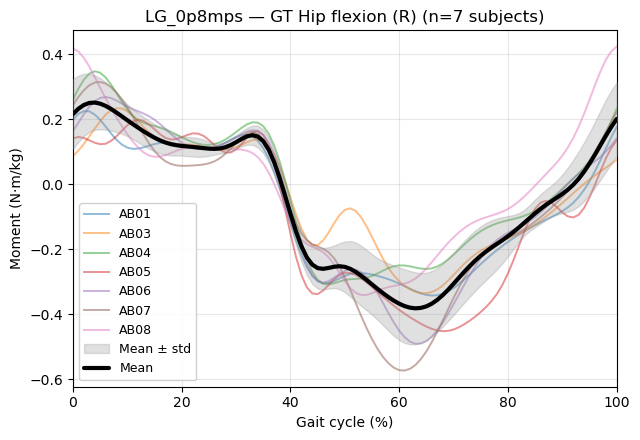

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_1p2mps.png


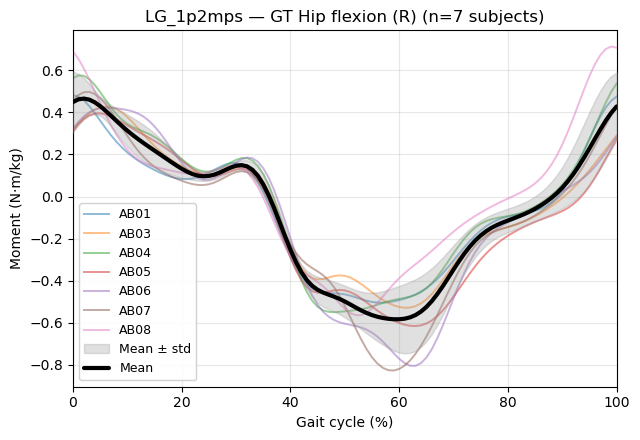

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_1p6mps.png


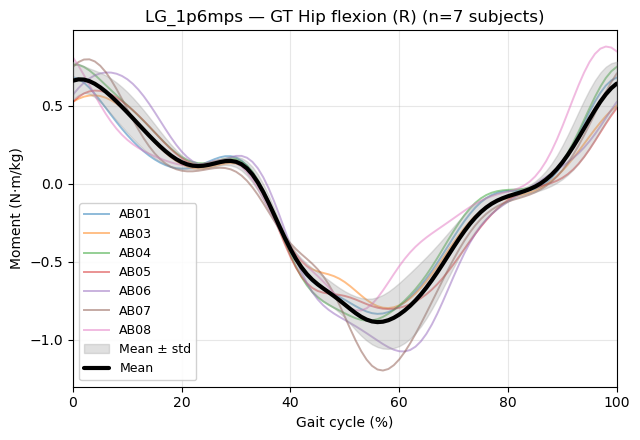

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_RA_0p8mps.png


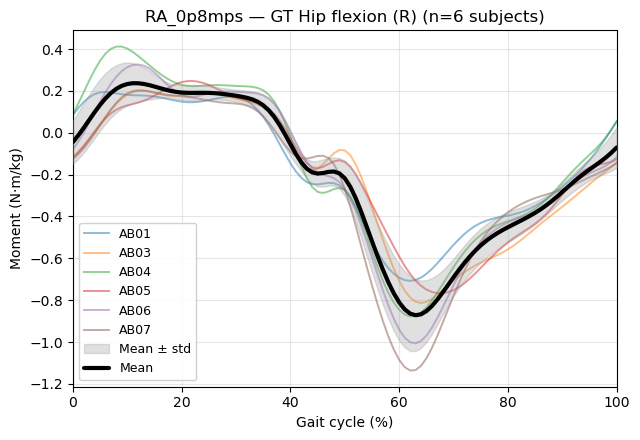

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_RD_0p8mps.png


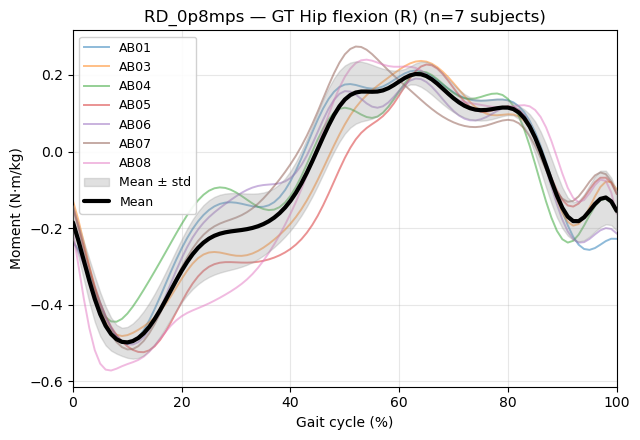


=== Plotting GT for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_0p8mps.png


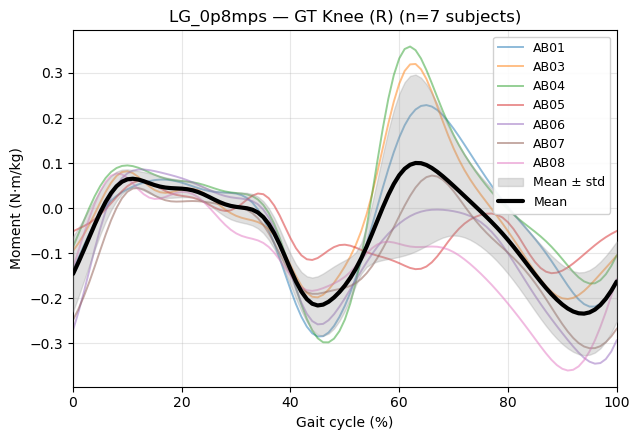

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_1p2mps.png


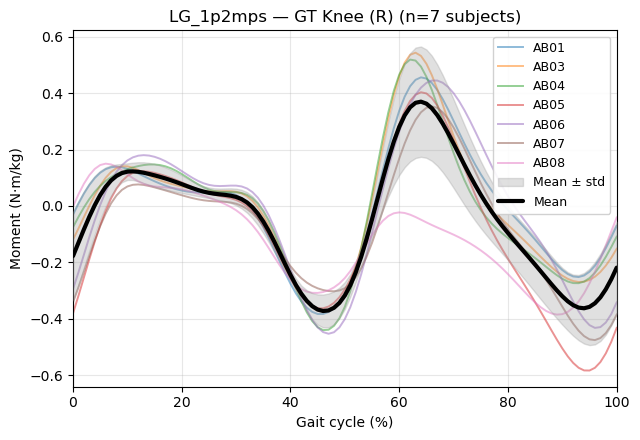

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_1p6mps.png


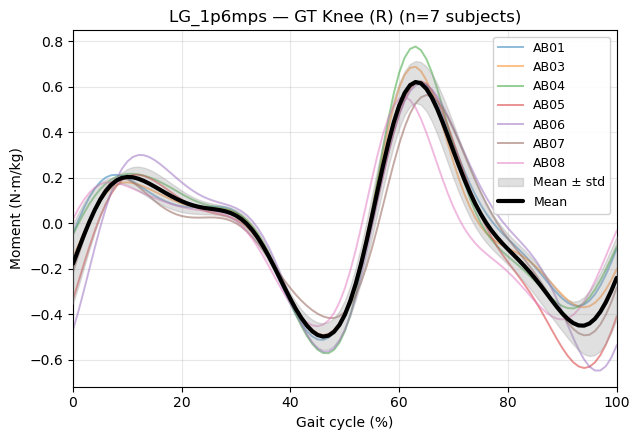

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_RA_0p8mps.png


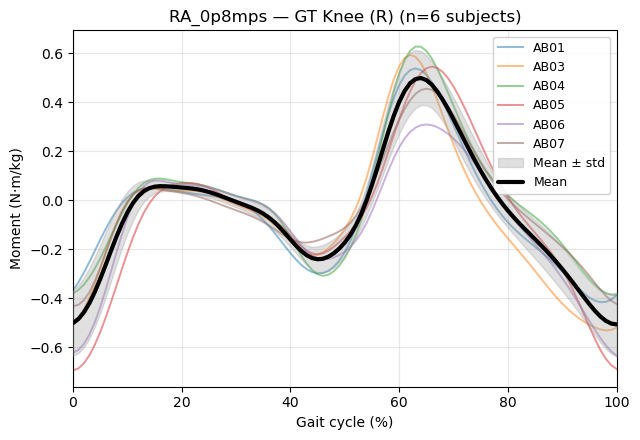

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_RD_0p8mps.png


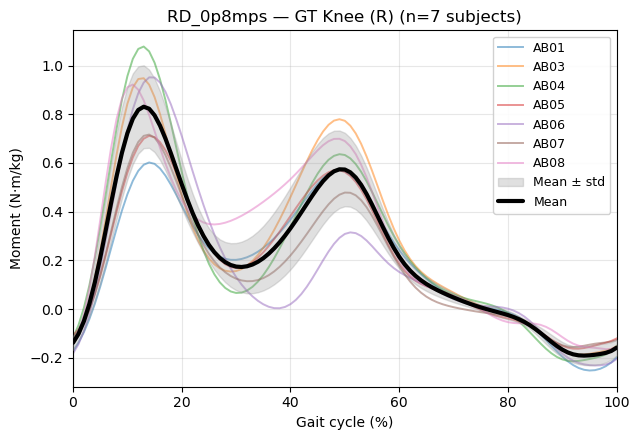


=== Plotting GT for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_0p8mps.png


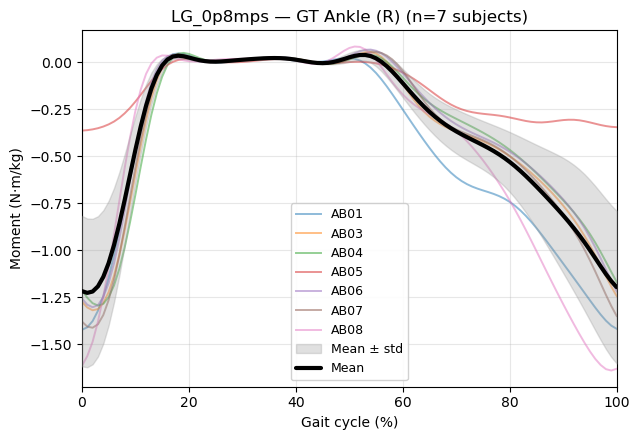

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_1p2mps.png


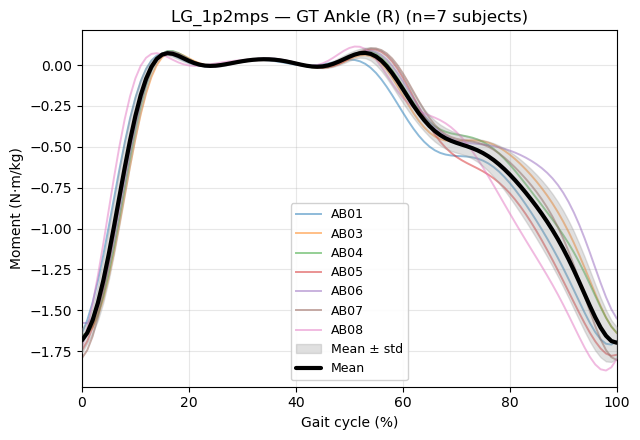

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_1p6mps.png


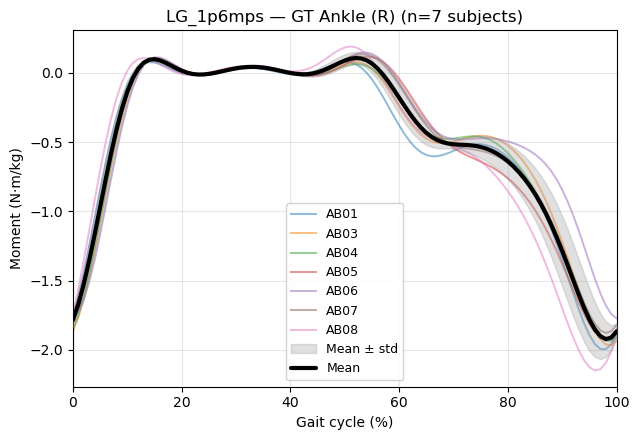

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_RA_0p8mps.png


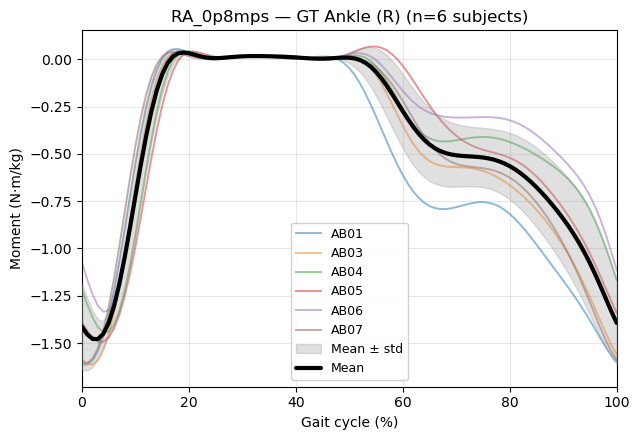

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_RD_0p8mps.png


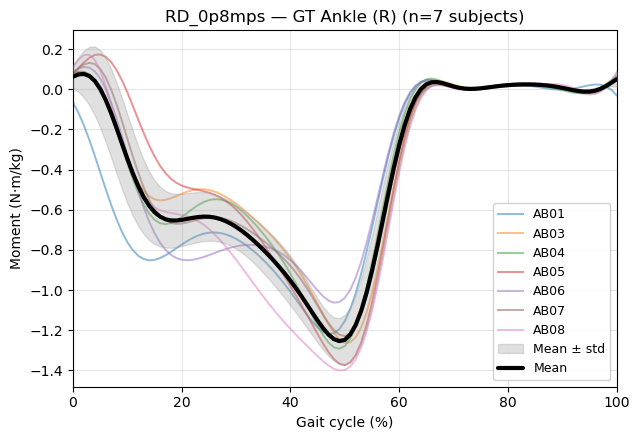

In [6]:
def plot_condition_joint_gt(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['gt_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')
        subj_id = subj.split('_')[0]
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — GT {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


conditions = sorted(GAIT_BY_CONDITION.keys())
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting GT for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_gt(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_gt_{joint_name}_{condition}.png',
        )

## 4. Plot model estimate gait-cycle moment profiles (per joint)


=== Plotting Model for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_0p8mps.png


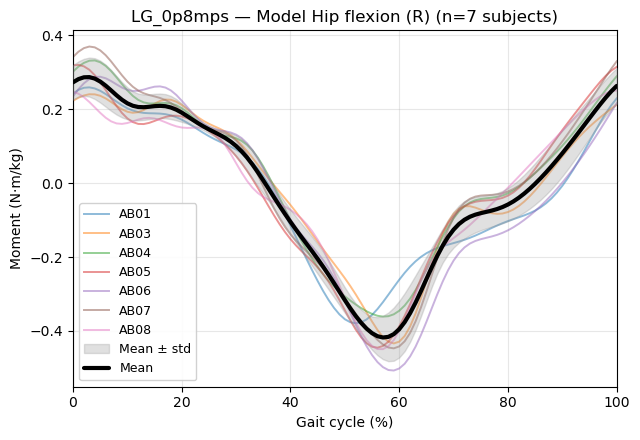

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_1p2mps.png


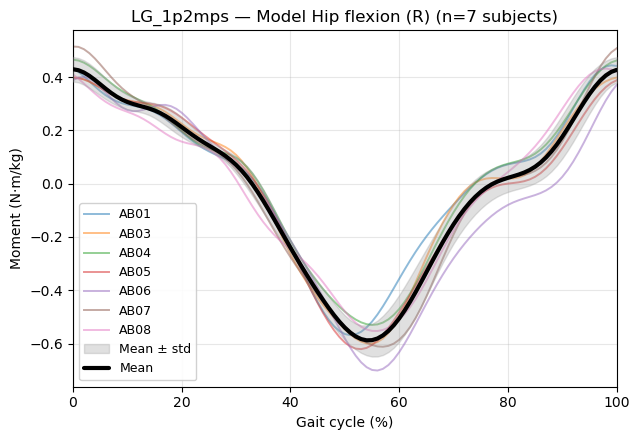

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_1p6mps.png


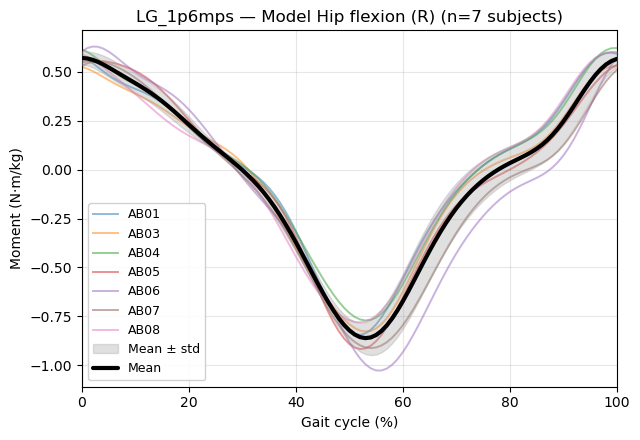

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_RA_0p8mps.png


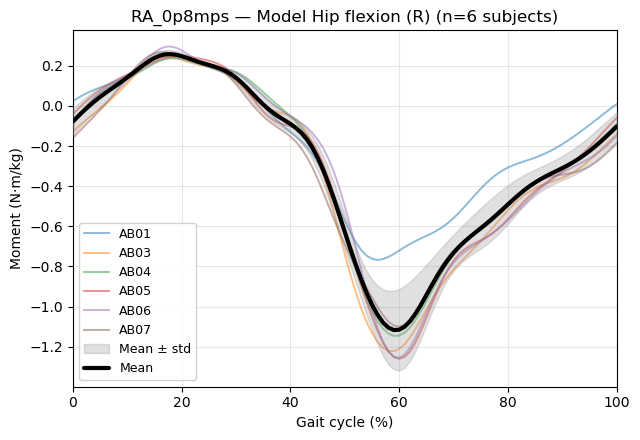

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_RD_0p8mps.png


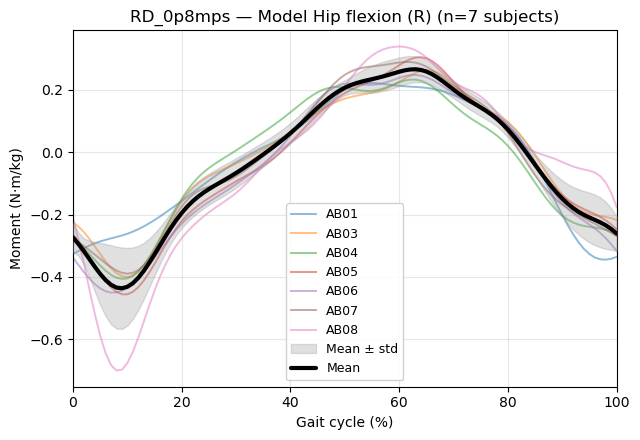


=== Plotting Model for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_0p8mps.png


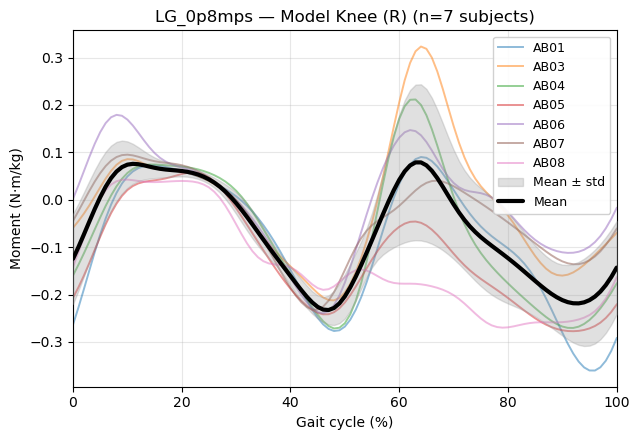

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_1p2mps.png


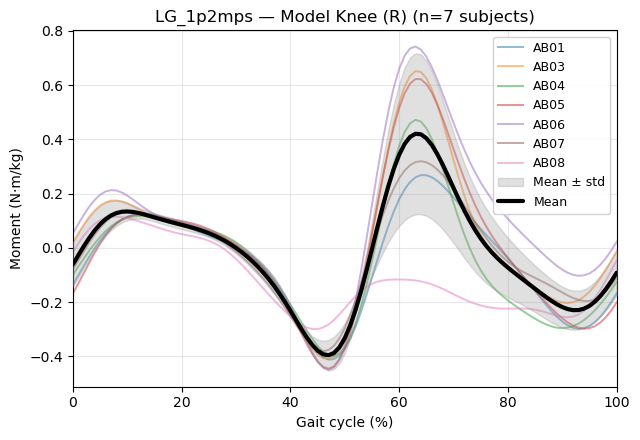

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_1p6mps.png


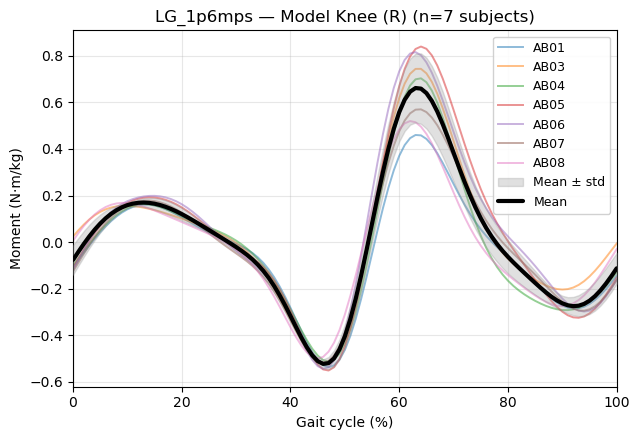

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_RA_0p8mps.png


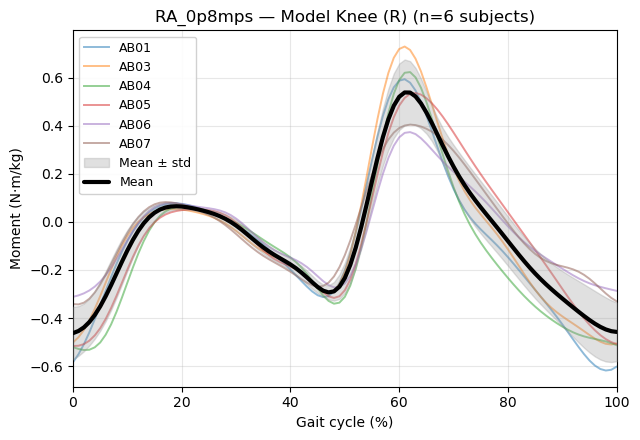

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_RD_0p8mps.png


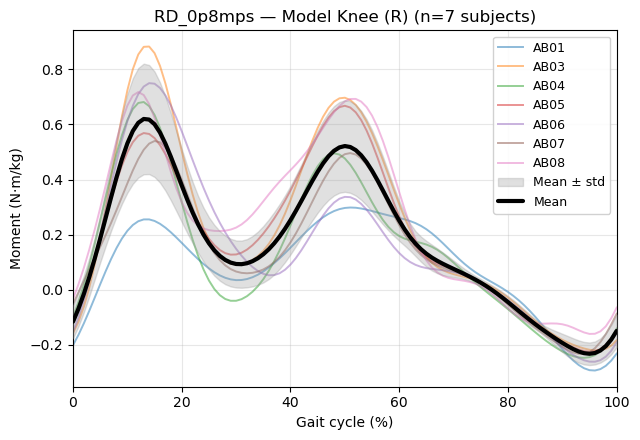


=== Plotting Model for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_0p8mps.png


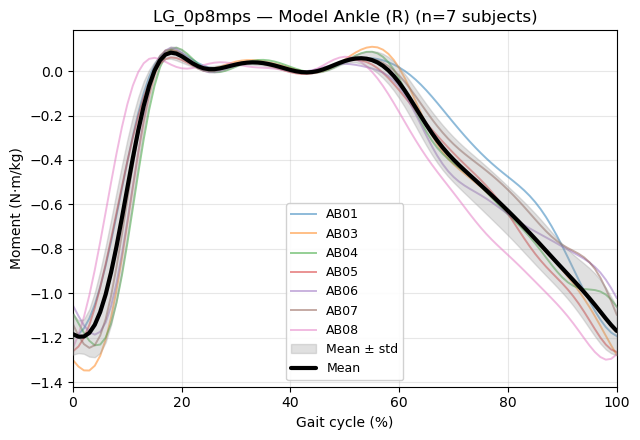

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_1p2mps.png


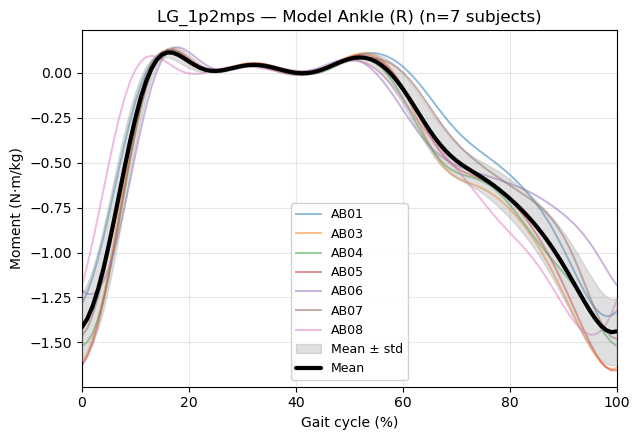

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_1p6mps.png


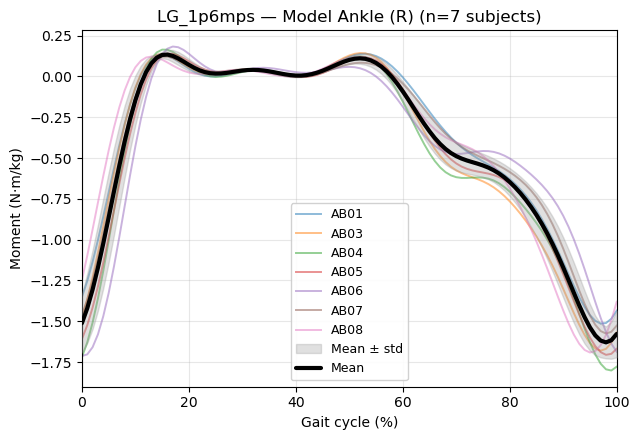

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_RA_0p8mps.png


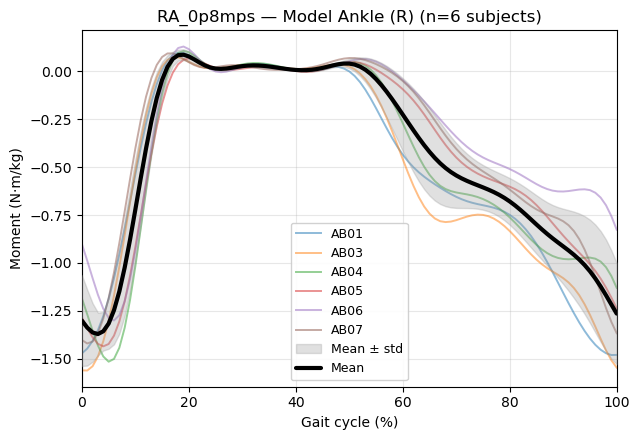

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_RD_0p8mps.png


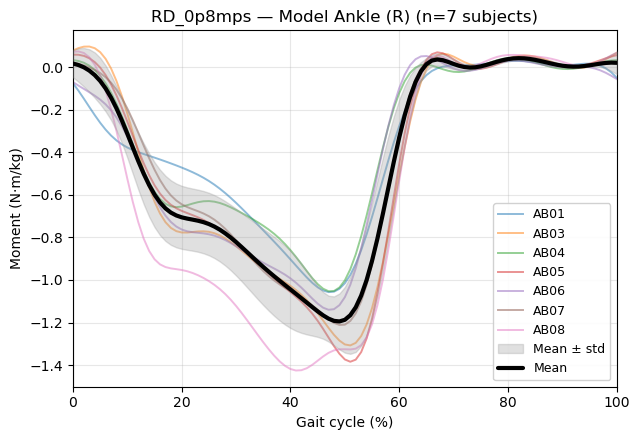

In [7]:
def plot_condition_joint_model(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['model_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')
        subj_id = subj.split('_')[0]
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — Model {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting Model for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_model(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_model_{joint_name}_{condition}.png',
        )

## 5. GT vs Model comparison (grand means only, per joint)


=== Plotting GT vs Model for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_0p8mps.png


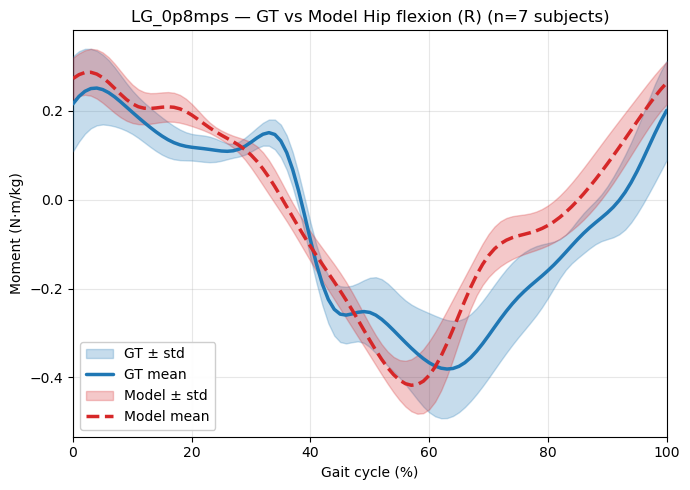

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_1p2mps.png


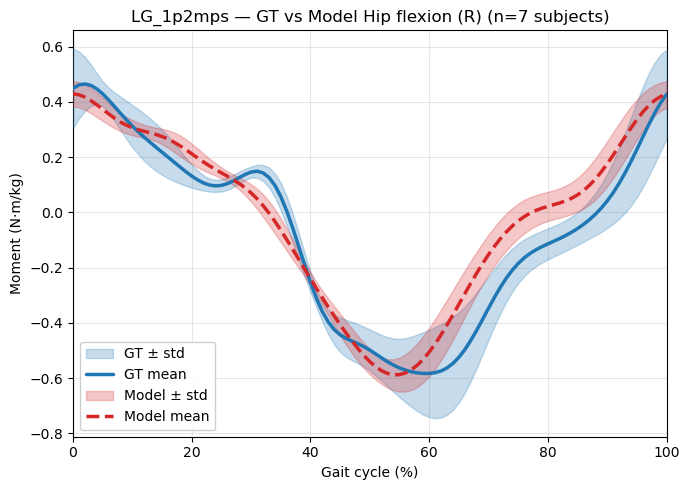

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_1p6mps.png


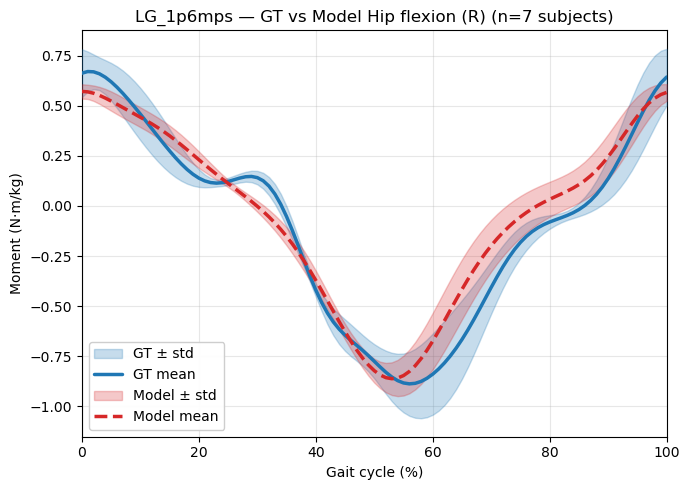

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_RA_0p8mps.png


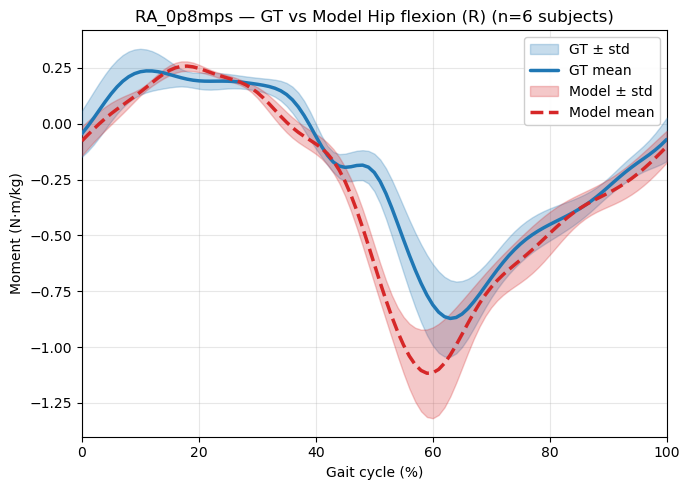

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_RD_0p8mps.png


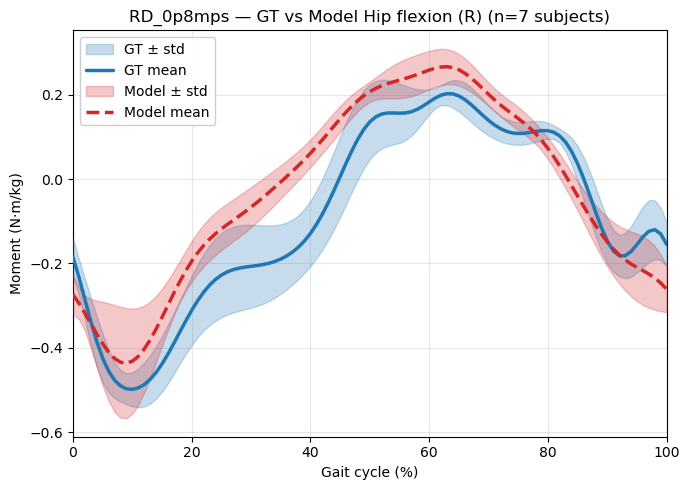


=== Plotting GT vs Model for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_0p8mps.png


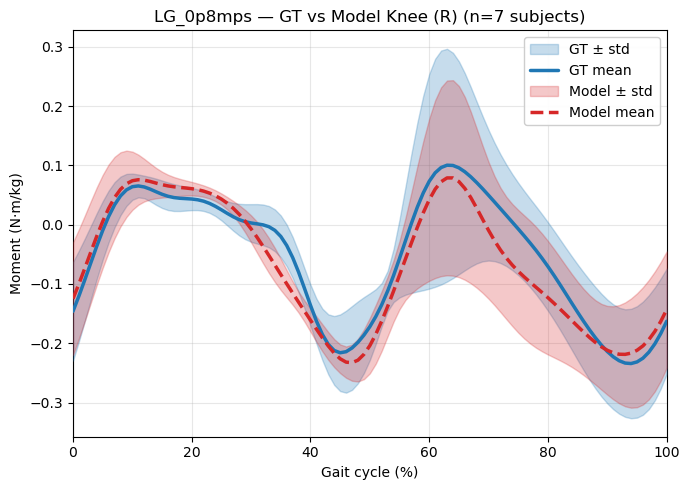

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_1p2mps.png


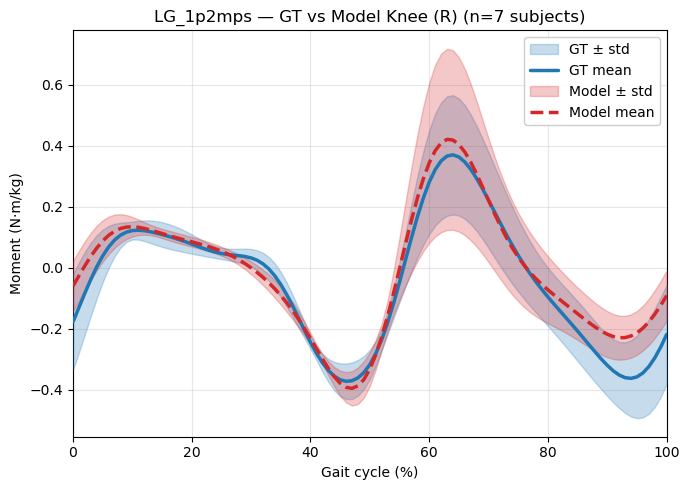

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_1p6mps.png


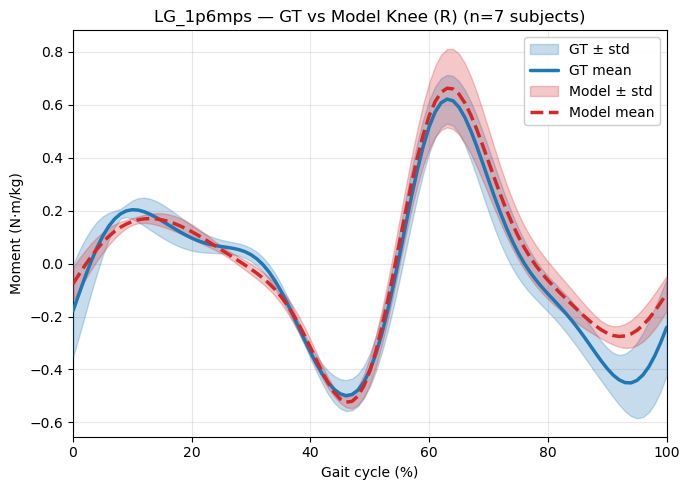

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_RA_0p8mps.png


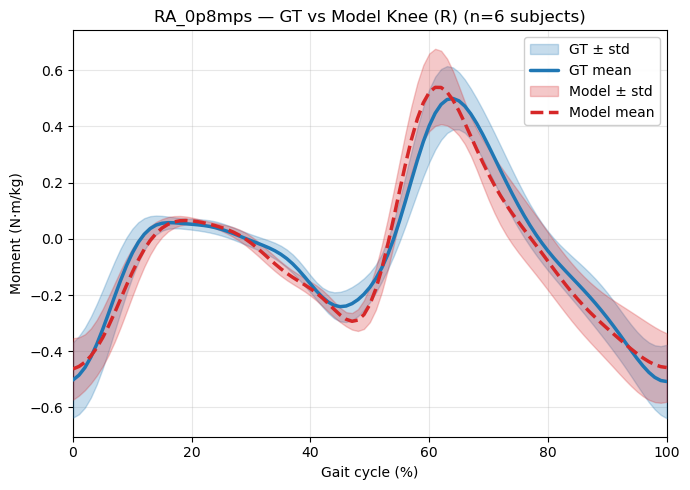

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_RD_0p8mps.png


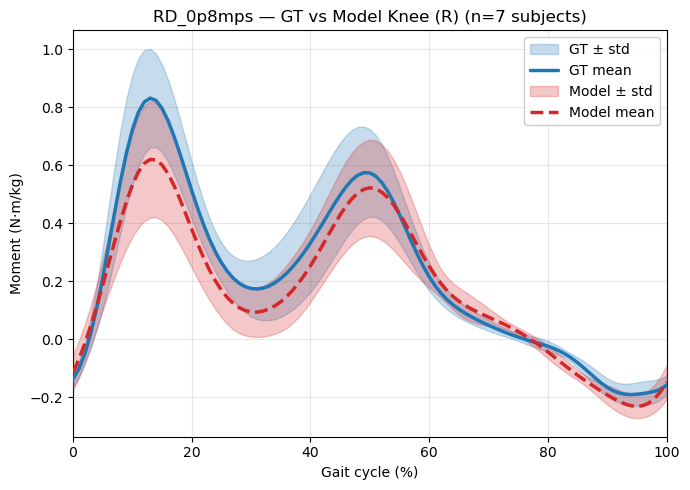


=== Plotting GT vs Model for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_0p8mps.png


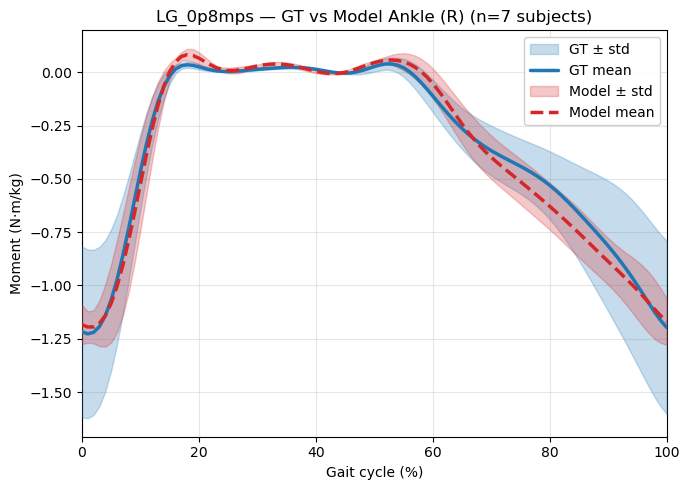

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_1p2mps.png


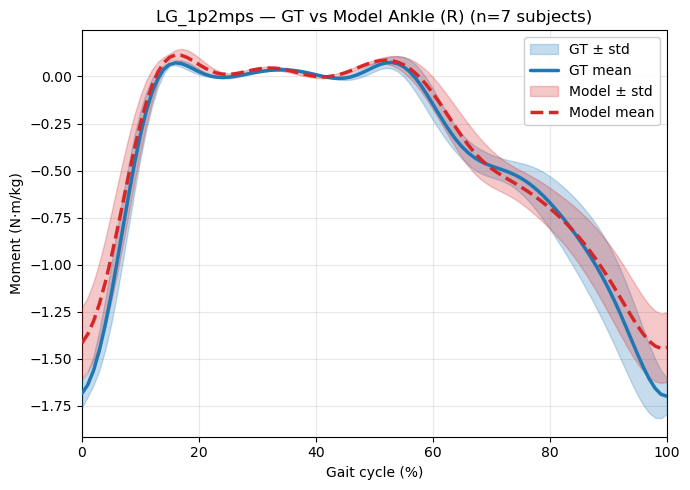

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_1p6mps.png


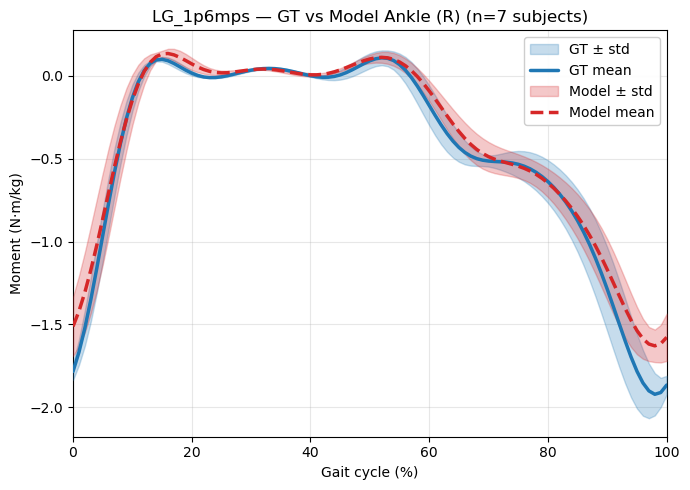

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_RA_0p8mps.png


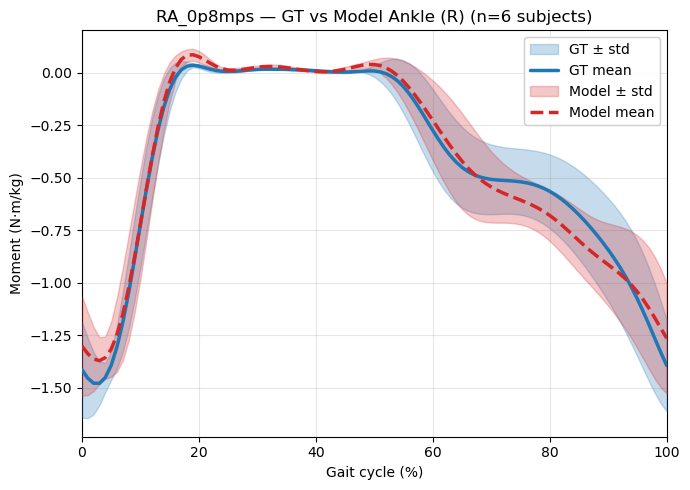

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_RD_0p8mps.png


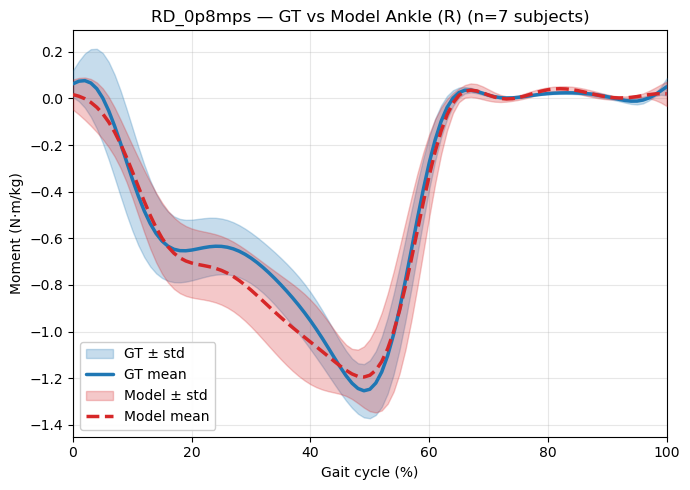

In [8]:
def plot_condition_joint_comparison(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    
    gt_subject_means = [np.asarray(t['gt_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    gt_grand_mean = np.mean(gt_subject_means, axis=0)
    gt_grand_std = np.std(gt_subject_means, axis=0, ddof=1) if len(gt_subject_means) > 1 else np.zeros_like(gt_grand_mean)
    
    model_subject_means = [np.asarray(t['model_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    model_grand_mean = np.mean(model_subject_means, axis=0)
    model_grand_std = np.std(model_subject_means, axis=0, ddof=1) if len(model_subject_means) > 1 else np.zeros_like(model_grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    gt_color = '#1f77b4'
    ax.fill_between(
        pct,
        gt_grand_mean - gt_grand_std,
        gt_grand_mean + gt_grand_std,
        color=gt_color,
        alpha=0.25,
        label='GT ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        gt_grand_mean,
        color=gt_color,
        lw=2.5,
        solid_capstyle='round',
        label='GT mean',
        zorder=10,
    )
    
    model_color = '#d62728'
    ax.fill_between(
        pct,
        model_grand_mean - model_grand_std,
        model_grand_mean + model_grand_std,
        color=model_color,
        alpha=0.25,
        label='Model ± std',
        zorder=6,
    )
    ax.plot(
        pct,
        model_grand_mean,
        color=model_color,
        lw=2.5,
        solid_capstyle='round',
        label='Model mean',
        zorder=11,
        linestyle='--',
    )
    
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — GT vs Model {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.95, fontsize=10)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting GT vs Model for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_comparison(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_comparison_{joint_name}_{condition}.png',
        )